In [15]:
import pandas as pd

# Keep original for comparison
df_original = pd.read_csv(r"/content/drive/MyDrive/Airbnb/Airbnb_Data.csv", on_bad_lines='skip', engine='python')
df = df_original.copy()                        # Working copy for cleaning

print(df.shape)
print(df.info())

df.head

(74111, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73

<bound method NDFrame.head of              id  log_price property_type        room_type  \
0       6901257   5.010635     Apartment  Entire home/apt   
1       6304928   5.129899     Apartment  Entire home/apt   
2       7919400   4.976734     Apartment  Entire home/apt   
3      13418779   6.620073         House  Entire home/apt   
4       3808709   4.744932     Apartment  Entire home/apt   
...         ...        ...           ...              ...   
74106  14549287   4.605170     Apartment     Private room   
74107  13281809   5.043425     Apartment  Entire home/apt   
74108  18688039   5.220356     Apartment  Entire home/apt   
74109  17045948   5.273000     Apartment  Entire home/apt   
74110   3534845   4.852030          Boat  Entire home/apt   

                                               amenities  accommodates  \
0      {"Wireless Internet","Air conditioning",Kitche...             3   
1      {"Wireless Internet","Air conditioning",Kitche...             7   
2      {TV,"Cable TV","Wireless Internet","Air condit...             5   
3      {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4   
4      {TV,Internet,"Wireless Internet","Air conditio...             2   
...                                                  ...           ...   
74106                                                 {}             1   
74107  {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4   
74108  {TV,Internet,"Wireless Internet","Air conditio...             5   
74109  {TV,"Wireless Internet","Air conditioning",Kit...             2   
74110  {TV,Internet,"Wireless Internet",Kitchen,"Free...             4   

       bathrooms  bed_type cancellation_policy  cleaning_fee  ...   latitude  \
0            1.0  Real Bed              strict          True  ...  40.696524   
1            1.0  Real Bed              strict          True  ...  40.766115   
2            1.0  Real Bed            moderate          True  ...  40.808110   
3            1.0  Real Bed            flexible          True  ...  37.772004   
4            1.0  Real Bed            moderate          True  ...  38.925627   
...          ...       ...                 ...           ...  ...        ...   
74106        1.0  Real Bed            flexible         False  ...  40.709025   
74107        2.0  Real Bed            moderate          True  ...  33.871549   
74108        1.0  Real Bed            moderate          True  ...  40.706749   
74109        1.0  Real Bed              strict          True  ...  40.738535   
74110        1.0  Real Bed            moderate         False  ...  33.761096   

        longitude                                        name  \
0      -73.991617              Beautiful brownstone 1-bedroom   
1      -73.989040    Superb 3BR Apt Located Near Times Square   
2      -73.943756                            The Garden Oasis   
3     -122.431619          Beautiful Flat in the Heart of SF!   
4      -77.034596                  Great studio in midtown DC   
...           ...                                         ...   
74106  -73.939405                           one room bushwick   
74107 -118.396053                Spacious Hermosa 2 BR on PCH   
74108  -73.942377  Modern 2 Bedroom Apartment in Williamsburg   
74109  -74.000157        Designer's Apartment in HEART of NYC   
74110 -118.192409              Cozy Boat at Shoreline Village   

          neighbourhood number_of_reviews review_scores_rating  \
0      Brooklyn Heights                 2                100.0   
1        Hell's Kitchen                 6                 93.0   
2                Harlem                10                 92.0   
3          Lower Haight                 0                  NaN   
4      Columbia Heights                 4                 40.0   
...                 ...               ...                  ...   
74106      Williamsburg                 0                  NaN   
74107     Hermosa Beach                16                 93.0   
74108      W

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# First, I handle missing values
# 1. For numerical columns, I am filling missing values with the median
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['beds'].fillna(df['beds'].median(), inplace=True)
df['review_scores_rating'].fillna(df['review_scores_rating'].median(), inplace=True)

# For categorical column "neighbourhood", I am filling missing values with the most common value (mode)
df['neighbourhood'].fillna(df['neighbourhood'].mode()[0], inplace=True)

# For host_response_rate, I don’t want to lose data, so I am filling missing values with "Unknown"
df['host_response_rate'].fillna("Unknown", inplace=True)

# 2. Next, I check and remove duplicate rows (if there are any)
df.drop_duplicates(inplace=True)

# 3️. Now, I convert text columns with dates into proper datetime format
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# 4️. Finally, I handle outliers in log_price
# I keep only the values between the 1st percentile and the 99th percentile
lower = df['log_price'].quantile(0.01)
upper = df['log_price'].quantile(0.99)
df = df[(df['log_price'] >= lower) & (df['log_price'] <= upper)]

# -------------------------------
# After cleaning, I check the results
# -------------------------------
print("Shape after cleaning:", df.shape)   # Number of rows and columns after cleaning
print("Missing values after cleaning:\n", df.isnull().sum().head(10))  # Check top 10 columns for missing values


/tmp/ipython-input-581939981.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
/tmp/ipython-input-581939981.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Shape after cleaning: (72651, 29)
Missing values after cleaning:
 id                     0
log_price              0
property_type          0
room_type              0
amenities              0
accommodates           0
bathrooms              0
bed_type               0
cancellation_policy    0
cleaning_fee           0
dtype: int64


Shape of dataset: (72651, 29)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 72651 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      72651 non-null  int64         
 1   log_price               72651 non-null  float64       
 2   property_type           72651 non-null  object        
 3   room_type               72651 non-null  object        
 4   amenities               72651 non-null  object        
 5   accommodates            72651 non-null  int64         
 6   bathrooms               72651 non-null  float64       
 7   bed_type                72651 non-null  object        
 8   cancellation_policy     72651 non-null  object        
 9   cleaning_fee            72651 non-null  bool          
 10  city                    72651 non-null  object        
 11  description             72651 non-null  object        
 12  first_

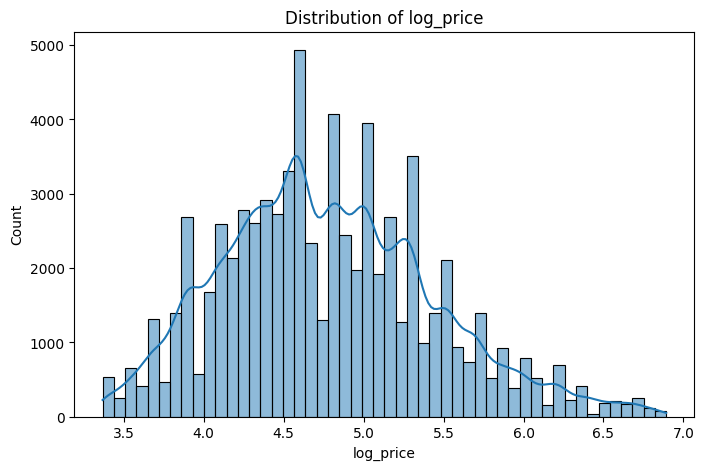

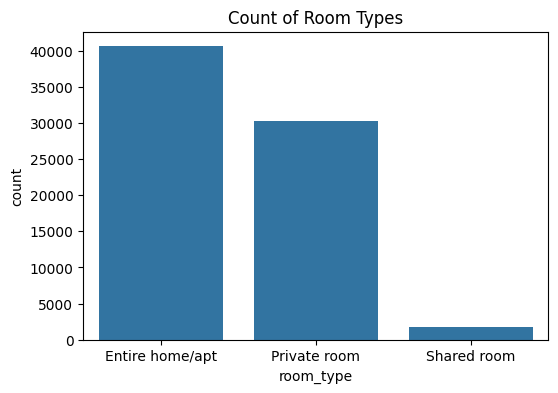

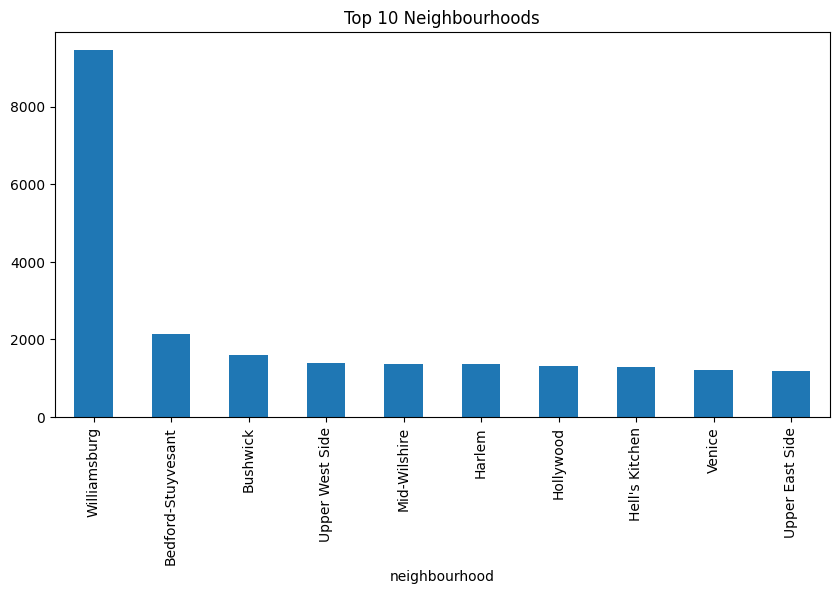

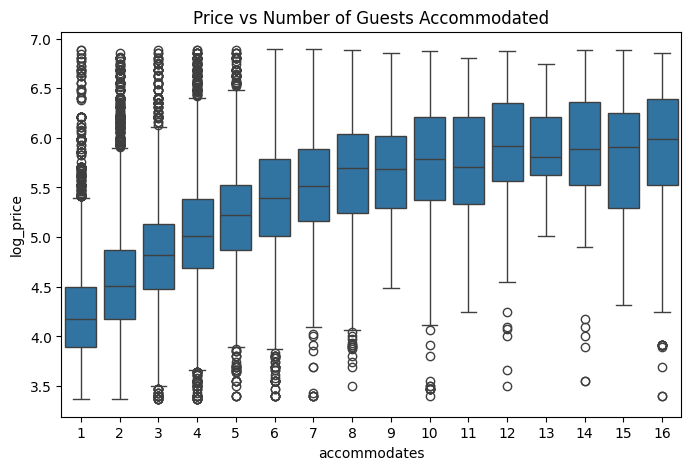

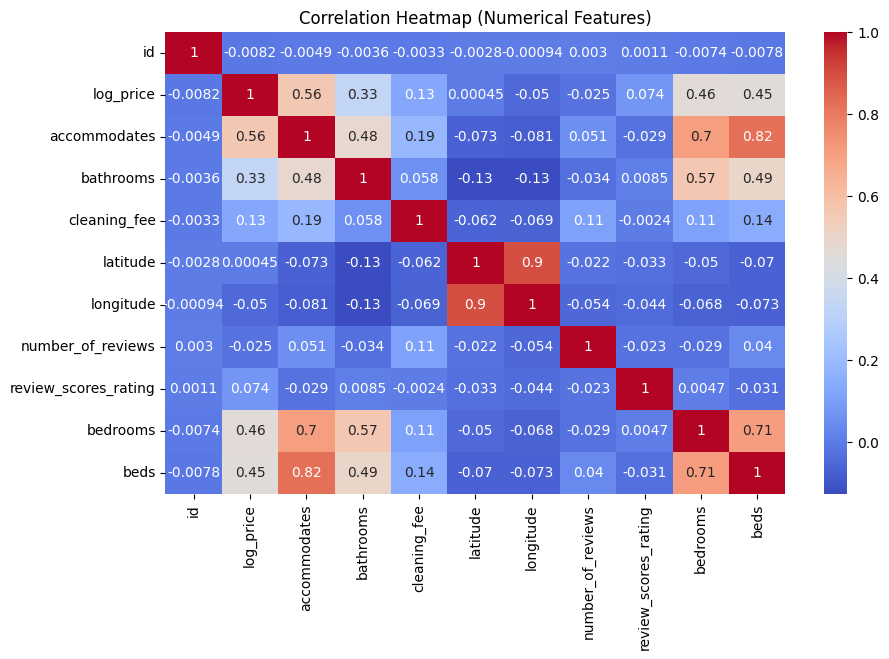

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Basic Info
print("Shape of dataset:", df.shape)  # rows and columns
print("\nDataset Info:")
print(df.info())  # column details

# 2️⃣ Summary of Numbers
print("\nSummary of Numerical Columns:")
print(df.describe())  # stats like mean, median, min, max

# 3️⃣ Check Top Cities
print("\nListings by City:")
print(df['city'].value_counts().head(10))

# 4️⃣ Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Distribution of log_price")
plt.show()

# 5️⃣ Room Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='room_type', data=df)
plt.title("Count of Room Types")
plt.show()

# 6️⃣ Neighbourhood (Top 10)
plt.figure(figsize=(10,5))
df['neighbourhood'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Neighbourhoods")
plt.show()

# 7️⃣ Relationship: Accommodates vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x='accommodates', y='log_price', data=df)
plt.title("Price vs Number of Guests Accommodated")
plt.show()

# 8️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

/tmp/ipython-input-3551603611.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_first_review'] = df['first_review'].dt.year
/tmp/ipython-input-3551603611.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_last_review'] = df['last_review'].dt.year


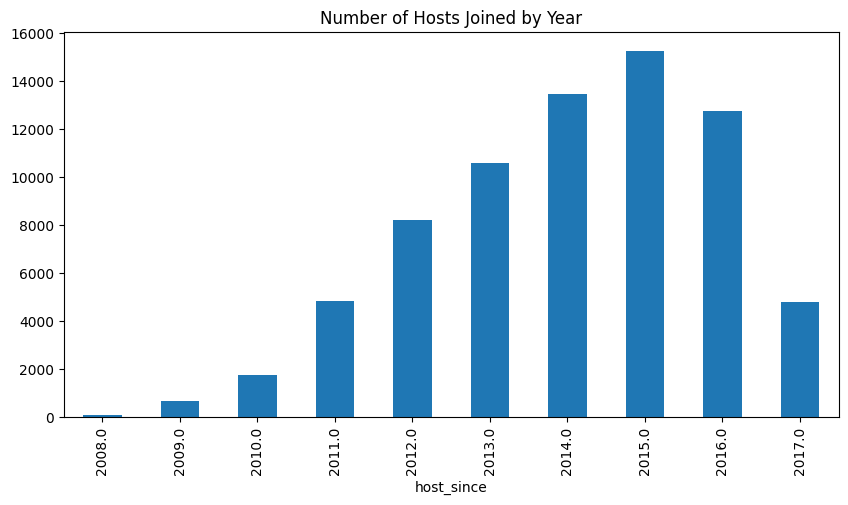

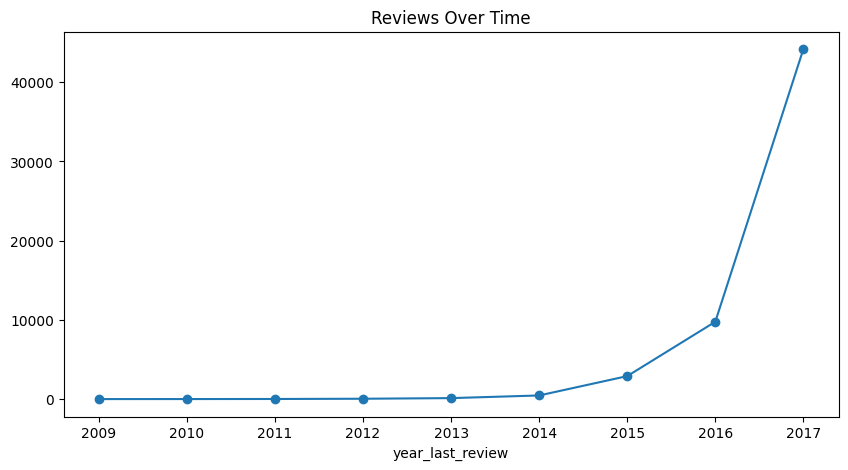

In [19]:
# Convert review dates properly
df['year_first_review'] = df['first_review'].dt.year
df['year_last_review'] = df['last_review'].dt.year

# Listings by host_since year
plt.figure(figsize=(10,5))
df['host_since'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title("Number of Hosts Joined by Year")
plt.show()

# Reviews per year
plt.figure(figsize=(10,5))
df['year_last_review'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Reviews Over Time")
plt.show()


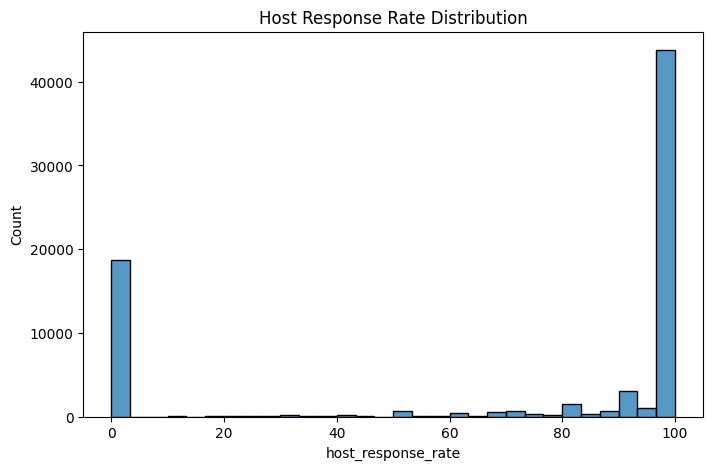

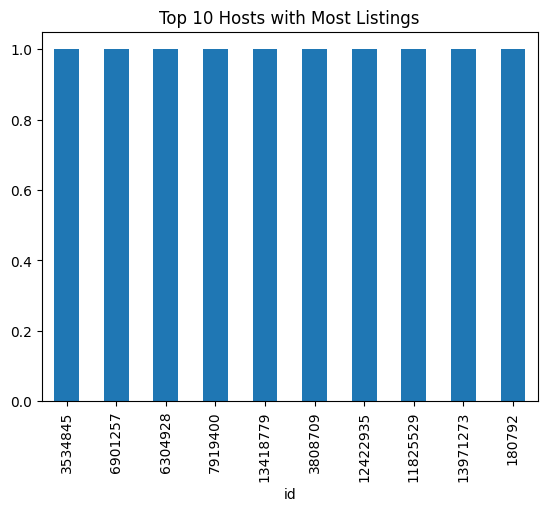

In [20]:
# Host response rate distribution
plt.figure(figsize=(8,5))
sns.histplot(df['host_response_rate'].replace("Unknown", "0").astype(str).str.replace("%","").astype(float), bins=30)
plt.title("Host Response Rate Distribution")
plt.show()

# Listings per host
top_hosts = df['id'].value_counts().head(10)
top_hosts.plot(kind='bar')
plt.title("Top 10 Hosts with Most Listings")
plt.show()


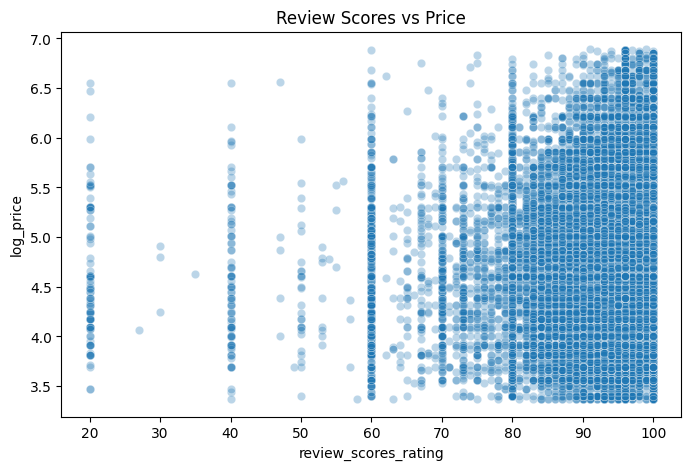

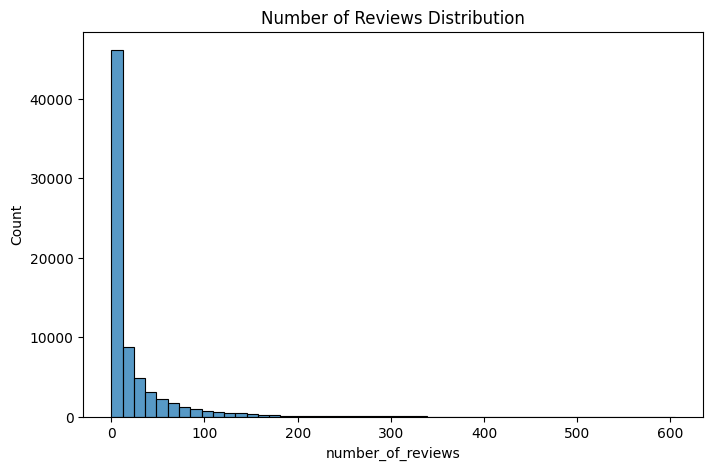

In [21]:
# Review Scores vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_scores_rating', y='log_price', data=df, alpha=0.3)
plt.title("Review Scores vs Price")
plt.show()

# Number of Reviews distribution
plt.figure(figsize=(8,5))
sns.histplot(df['number_of_reviews'], bins=50)
plt.title("Number of Reviews Distribution")
plt.show()


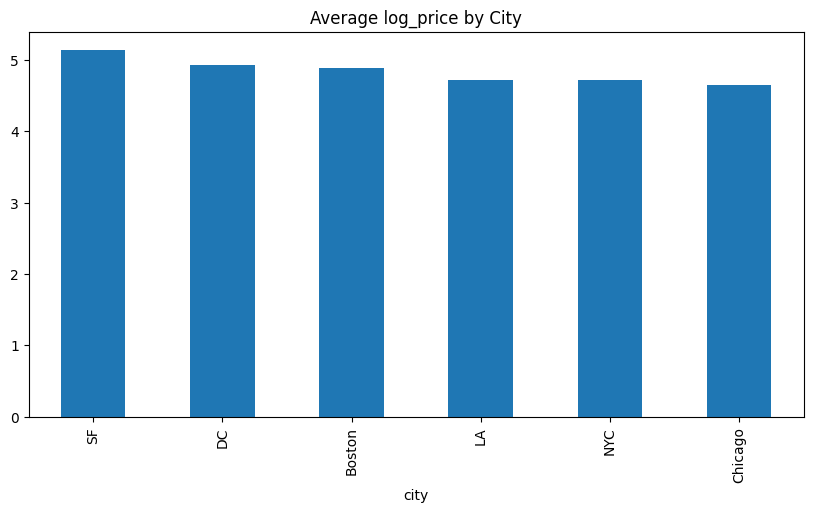

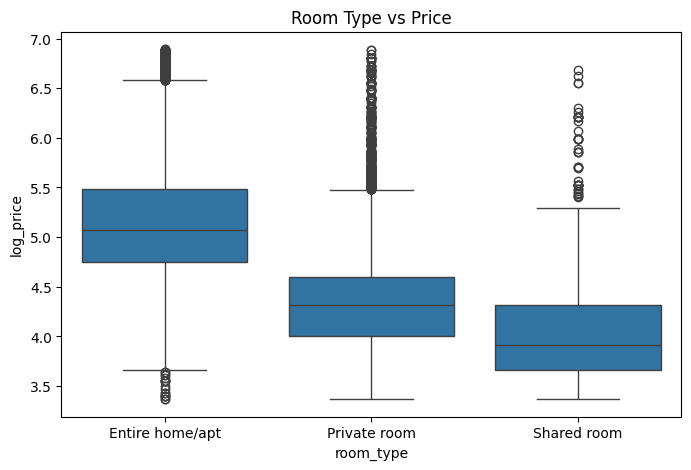

In [22]:
# Average Price by City
plt.figure(figsize=(10,5))
df.groupby('city')['log_price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average log_price by City")
plt.show()

# Room type vs price (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='log_price', data=df)
plt.title("Room Type vs Price")
plt.show()


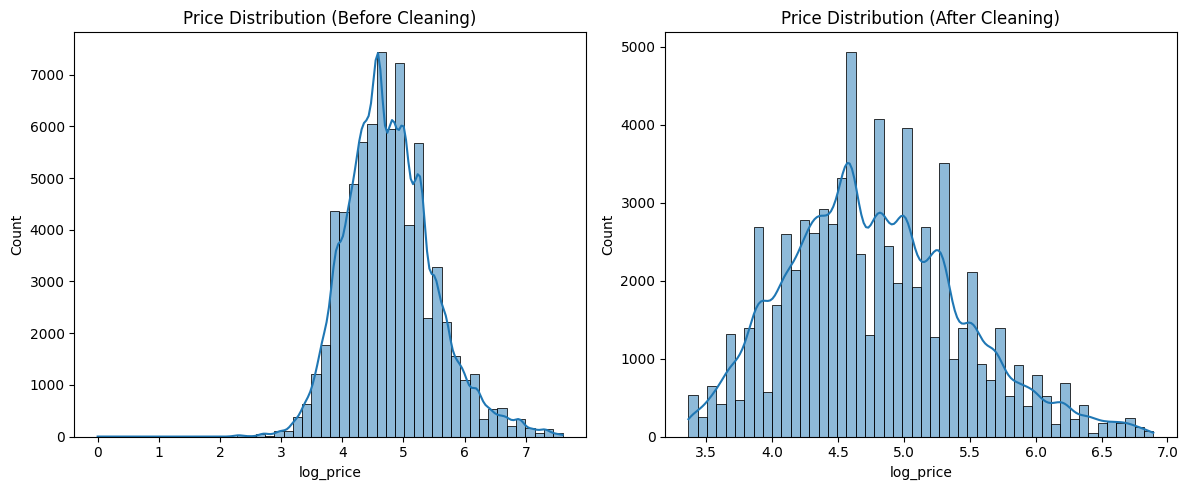

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare Price Distribution Before vs After Cleaning

plt.figure(figsize=(12,5))

# Before cleaning
plt.subplot(1,2,1)
sns.histplot(df_original['log_price'], bins=50, kde=True)
plt.title("Price Distribution (Before Cleaning)")

# After cleaning
plt.subplot(1,2,2)
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Price Distribution (After Cleaning)")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2912788037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = np.exp(df['log_price'])


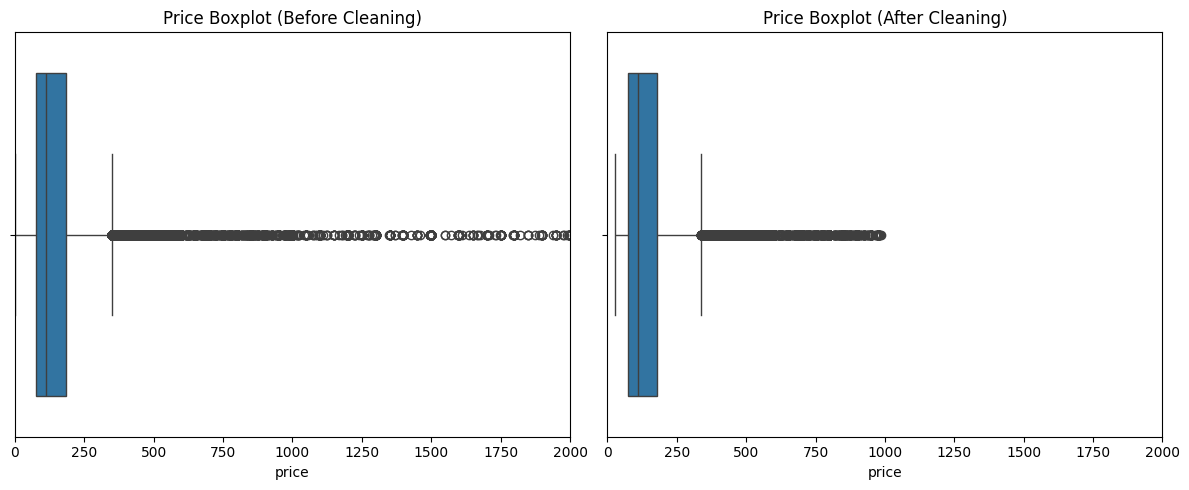

In [29]:
# Add real price columns (exponentiate log_price)
df_original['price'] = np.exp(df_original['log_price'])
df['price'] = np.exp(df['log_price'])

plt.figure(figsize=(12,5))

# Before cleaning
plt.subplot(1,2,1)
sns.boxplot(x=df_original['price'])
plt.xlim(0, 2000)  # focus on 0–2000 range
plt.title("Price Boxplot (Before Cleaning)")

# After cleaning
plt.subplot(1,2,2)
sns.boxplot(x=df['price'])
plt.xlim(0, 2000)  # same scale for comparison
plt.title("Price Boxplot (After Cleaning)")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2057940706.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, ci=None)


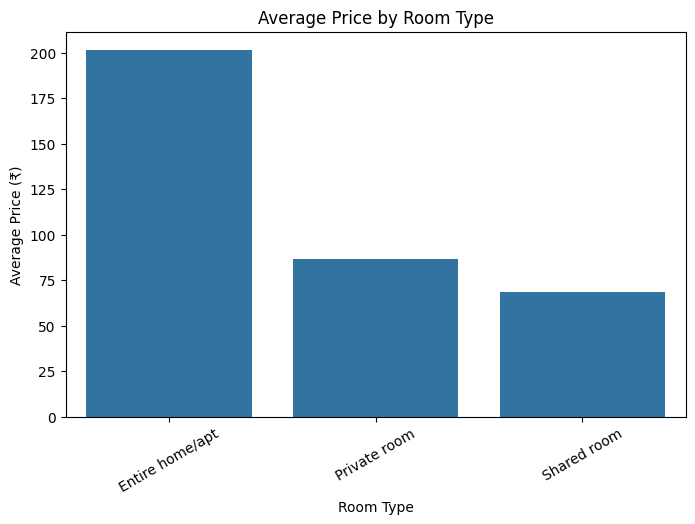

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, ci=None)
plt.title("Average Price by Room Type")
plt.ylabel("Average Price (₹)")
plt.xlabel("Room Type")
plt.xticks(rotation=30)
plt.show()


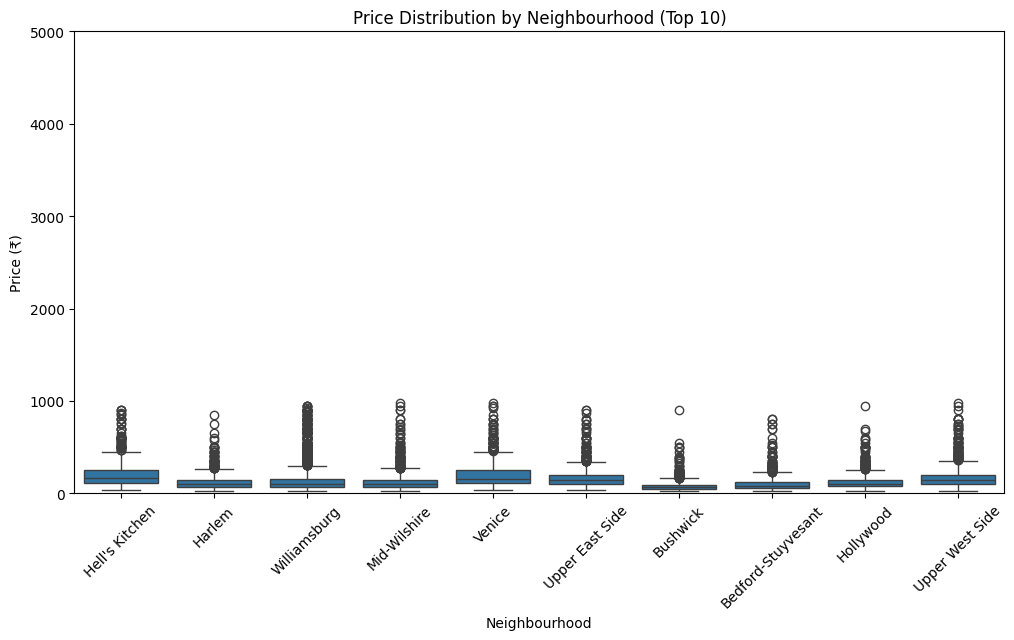

In [31]:
# Get top 10 neighbourhoods by listing count
top_neigh = df['neighbourhood'].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x="neighbourhood", y="price", data=df[df['neighbourhood'].isin(top_neigh)])
plt.title("Price Distribution by Neighbourhood (Top 10)")
plt.ylabel("Price (₹)")
plt.xlabel("Neighbourhood")
plt.xticks(rotation=45)
plt.ylim(0, 5000)   # focus on main range
plt.show()


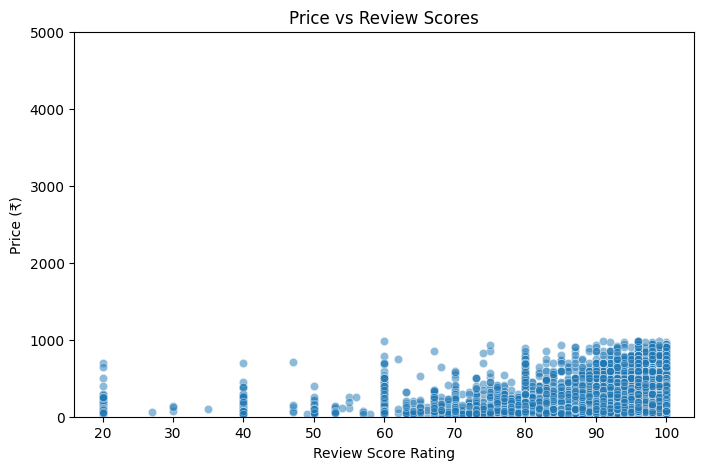

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="review_scores_rating", y="price", data=df, alpha=0.5)
plt.title("Price vs Review Scores")
plt.ylabel("Price (₹)")
plt.xlabel("Review Score Rating")
plt.ylim(0, 5000)   # limit y-axis to avoid outlierAs
plt.show()


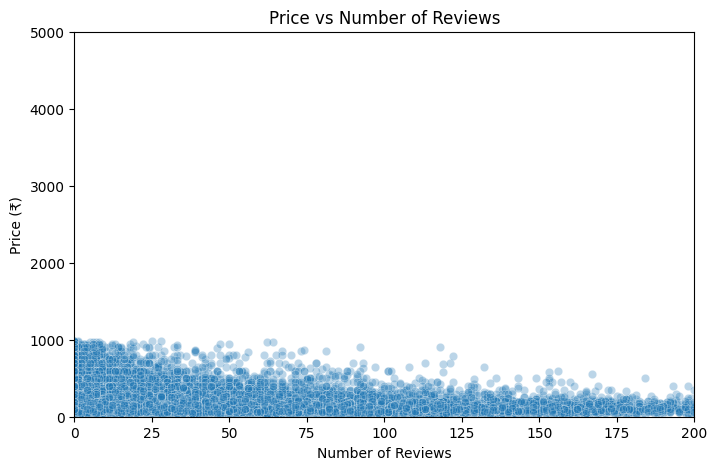

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="number_of_reviews", y="price", data=df, alpha=0.3)
plt.title("Price vs Number of Reviews")
plt.ylabel("Price (₹)")
plt.xlabel("Number of Reviews")
plt.ylim(0, 5000)
plt.xlim(0, 200)   # focus on listings with <200 reviews
plt.show()


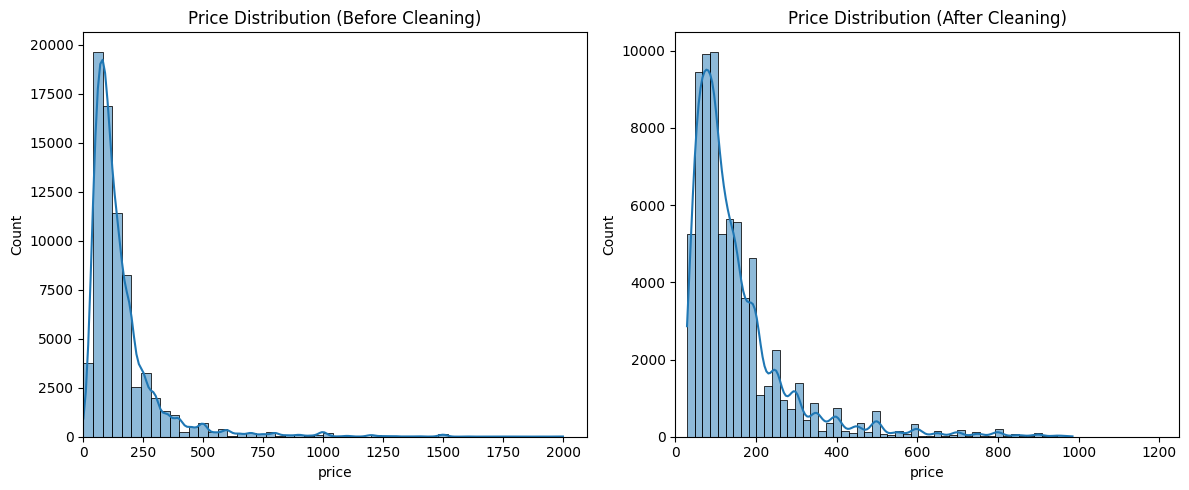

In [34]:
plt.figure(figsize=(12,5))

# Before Cleaning
plt.subplot(1,2,1)
sns.histplot(df_original['price'], bins=50, kde=True)
plt.xlim(0, 2100)
plt.title("Price Distribution (Before Cleaning)")

# After Cleaning
plt.subplot(1,2,2)
sns.histplot(df['price'], bins=50, kde=True)
plt.xlim(0, 1250)
plt.title("Price Distribution (After Cleaning)")

plt.tight_layout()
plt.show()


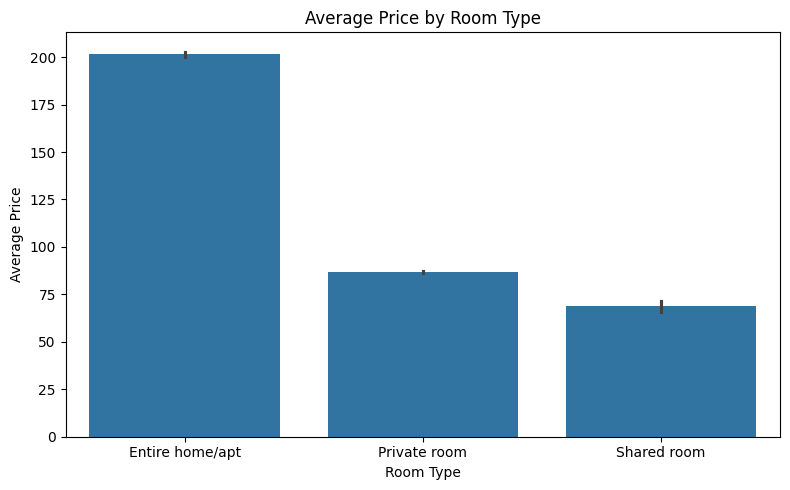

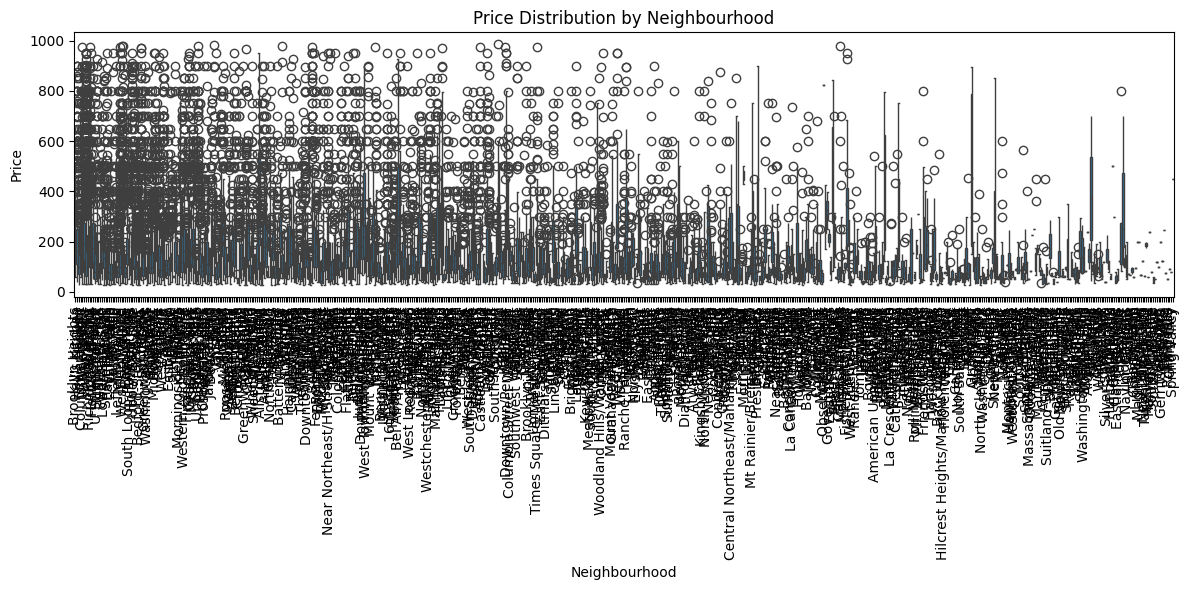

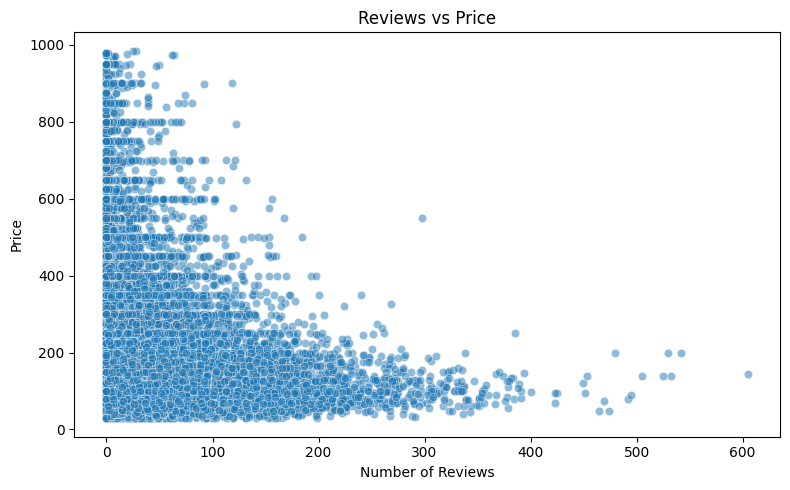

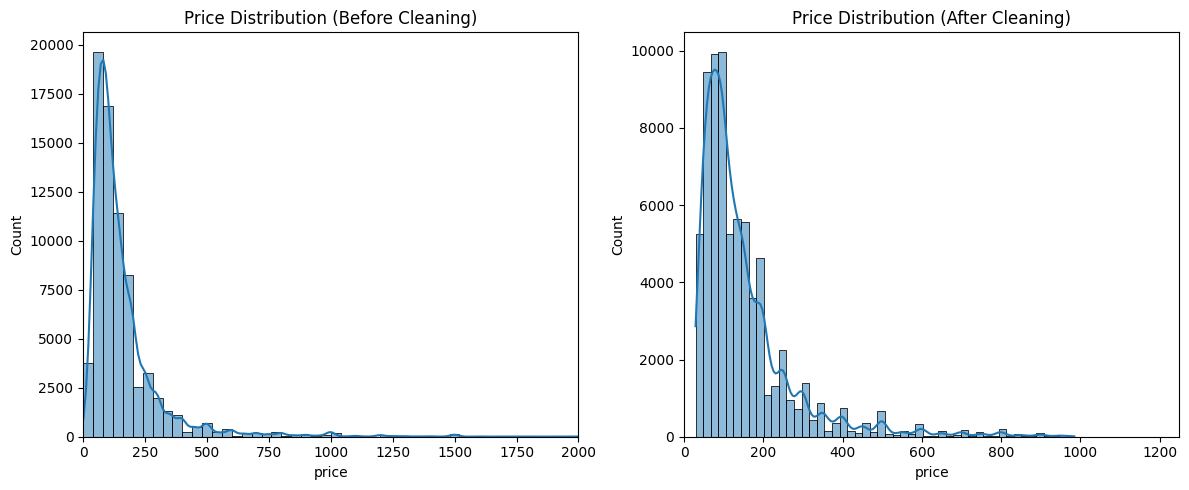

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Room Type & Pricing
plt.figure(figsize=(8,5))
sns.barplot(x='room_type', y='price', data=df, estimator='mean')
plt.title("Average Price by Room Type")
plt.ylabel("Average Price")
plt.xlabel("Room Type")
plt.tight_layout()
plt.savefig("room_type_price.png", dpi=300)
plt.show()

# 2️⃣ Neighbourhood Trends
plt.figure(figsize=(12,6))
sns.boxplot(x='neighbourhood', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Price Distribution by Neighbourhood")
plt.ylabel("Price")
plt.xlabel("Neighbourhood")
plt.tight_layout()
plt.savefig("neighbourhood_boxplot.png", dpi=300)
plt.show()

# 3️⃣ Reviews & Ratings Influence
plt.figure(figsize=(8,5))
sns.scatterplot(x='number_of_reviews', y='price', data=df, alpha=0.5)
plt.title("Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("reviews_price.png", dpi=300)
plt.show()

# 4️⃣ Effect of Cleaning (Before vs After)
plt.figure(figsize=(12,5))

# Before cleaning
plt.subplot(1,2,1)
sns.histplot(df_original['price'], bins=50, kde=True)
plt.xlim(0, 2000)
plt.title("Price Distribution (Before Cleaning)")

# After cleaning
plt.subplot(1,2,2)
sns.histplot(df['price'], bins=50, kde=True)
plt.xlim(0, 1250)
plt.title("Price Distribution (After Cleaning)")

plt.tight_layout()
plt.savefig("before_after_price.png", dpi=300)
plt.show()
